# Visual Tournament
**PoliMi GSOM Algorithmic Trading 2026**

Runs a full RMSC04 day for each of the three sample student agents on the
**same background market** (identical `seed`), then **gradually reveals**
their intraday mark-to-market P&L on a single chart — the curves grow
one simulated minute at a time, so the winner only becomes clear as the
trading day plays out.

---
**How to use:** *Run All*.  Edit the `AGENTS` list in Section 1 to swap in
your own teams; the simulation and animation will pick them up automatically.

> **Note on the animation.** ABIDES is event-driven and `abides.run()`
> is a single blocking call — there is no streaming hook into the kernel.
> So we run each simulation to completion first (fast, a few minutes
> total), then **replay** the P&L curves minute-by-minute.  The visual
> effect is identical to a live race; only the bookkeeping is done
> up-front.


## 0 · Imports

In [7]:
import os, sys, time

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from abides_core import abides
from abides_core.utils import parse_logs_df, ns_date
from abides_markets.configs.rmsc04 import build_config
from abides_markets.utils import config_add_agents

from student_work.mean_reversion_agent     import MeanReversionAgent
from student_work.trend_follower_agent     import TrendFollowerAgent
from student_work.liquidity_provider_agent import LiquidityProviderAgent

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

## 1 · Configuration  ← edit here

`AGENTS` lists every team in the tournament.  Each entry is
`(AgentClass, display_label, plot_color)`; add or swap rows to register
your own teams.  All agents share the same background market (one
simulation per agent, same `SEED`).

In [8]:
SEED          = 110
END_TIME      = "17:30:00"   # use "10:00:00" for a quick preview
TICKER        = "ABM"
STARTING_CASH = 10_000_000   # cents

AGENTS = [
    (MeanReversionAgent,     "Group A - Mean Reversion",     "#3498db"),
    (TrendFollowerAgent,     "Group B - Trend Follower",     "#e67e22"),
    (LiquidityProviderAgent, "Group C - Liquidity Provider", "#9b59b6"),
]

# ── Animation pacing ──────────────────────────────────────────────────────
# The chart redraws once per minute of *simulated* time.  PAUSE_S controls
# how long each frame lingers in *wall-clock* seconds; tune for taste.
#   end_time 17:30:00 → 480 simulated minutes
#     PAUSE_S = 0.04  → ~19 s reveal   (default — punchy)
#     PAUSE_S = 0.10  → ~48 s reveal   (more dramatic)
#     PAUSE_S = 0.00  → as fast as the renderer can keep up
PAUSE_S = 0.04

# ── Chart breathing room ──────────────────────────────────────────────────
# Pad the right edge of the x-axis by a few minutes so the final fill and
# the live "now" cursor don't sit on the chart border.
RIGHT_PAD_S = 10 * 60   # 10 minutes

## 2 · Helper functions

Mid-price extraction, fill extraction, and intraday P&L reconstruction —
all carried over verbatim from Section 6 of `agent_trades.ipynb` so this
notebook is fully self-contained.

In [9]:
def extract_price(end_state, ticker):
    """Mid-price series from L1 order-book snapshots."""
    ob = end_state["agents"][0].order_books[ticker]
    L1 = ob.get_L1_snapshots()
    bids = pd.DataFrame(L1["best_bids"], columns=["time", "price", "qty"]) \
        .dropna(subset=["time"])
    asks = pd.DataFrame(L1["best_asks"], columns=["time", "price", "qty"]) \
        .dropna(subset=["time"])

    def to_tod_s(ns_arr):
        return ((ns_arr - ns_arr.apply(ns_date)) / 1e9).astype(float)

    bids["tod"] = to_tod_s(bids["time"])
    asks["tod"] = to_tod_s(asks["time"])
    price = pd.merge_asof(
        bids[["tod", "price"]].rename(columns={"price": "bid"}),
        asks[["tod", "price"]].rename(columns={"price": "ask"}),
        on="tod",
    )
    price["bid"] = pd.to_numeric(price["bid"], errors="coerce")
    price["ask"] = pd.to_numeric(price["ask"], errors="coerce")
    price = price.dropna(subset=["bid", "ask"])
    price["mid"] = (price["bid"] + price["ask"]) / 2
    return price


def extract_fills(end_state, agent_id):
    """ORDER_EXECUTED events for one agent."""
    logs = parse_logs_df(end_state)
    mask = (logs["agent_id"] == agent_id) & (logs["EventType"] == "ORDER_EXECUTED")
    fills = logs[mask].copy()
    if fills.empty:
        return fills
    fills["tod"]        = (fills["EventTime"]
                           - fills["EventTime"].apply(ns_date)) / 1e9
    fills["is_buy"]     = fills["side"].apply(lambda s: s.is_bid())
    fills["signed_qty"] = fills.apply(
        lambda r: r["quantity"] if r["is_buy"] else -r["quantity"], axis=1)
    fills["inventory"]  = fills["signed_qty"].cumsum()
    return fills


def intraday_pnl(price, fills, starting_cash):
    """Mark-to-market P&L series (USD), inventory marked to mid."""
    if fills.empty:
        return pd.DataFrame({"tod": price["tod"].values,
                             "pnl": np.zeros(len(price))})
    pf = fills[["tod", "signed_qty", "fill_price", "inventory"]] \
        .sort_values("tod").copy()
    pf["cash"] = starting_cash - (pf["signed_qty"] * pf["fill_price"]).cumsum()
    pnl = pd.merge_asof(
        price[["tod", "mid"]],
        pf[["tod", "cash", "inventory"]],
        on="tod",
    )
    pnl["cash"]      = pnl["cash"].fillna(starting_cash)
    pnl["inventory"] = pnl["inventory"].fillna(0)
    pnl["pnl"] = (pnl["cash"] + pnl["inventory"] * pnl["mid"]
                  - starting_cash) / 100
    return pnl[["tod", "pnl"]]


def fmt_xaxis(ax, start_s=9.5*3600, end_s=17.5*3600, step_s=3600,
              right_pad_s=10*60):
    """Label the x-axis as HH:MM, with a small breathing-room pad."""
    ticks = np.arange(start_s, end_s + 1, step_s)
    labels = [f"{int(t//3600):02d}:{int((t%3600)//60):02d}" for t in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlim(start_s, end_s + right_pad_s)

## 3 · Run one full day per agent

Each agent gets its own simulation on the **same background market**
(same `SEED`, no MomentumAgents).  We mirror Section 2 of
`agent_trades.ipynb` byte-for-byte so each agent's curve here is
identical to the one it would produce on its own.

In [10]:
results = {}
for cls, label, _ in AGENTS:
    np.random.seed(SEED)
    cfg = build_config(
        seed=SEED, end_time=END_TIME, num_momentum_agents=0,
        log_orders=False, exchange_log_orders=False,
        book_logging=True, book_log_depth=1,
        stdout_log_level="WARNING", starting_cash=STARTING_CASH,
    )
    sid = len(cfg["agents"])
    # Seed the agent exactly as the single-agent notebook does: np.random
    # was just reset to SEED and build_config above consumed the same
    # entropy, so this randint draw matches.  Each agent's run here
    # therefore reproduces its single-agent run from agent_trades.ipynb.
    ag  = cls(
        id=sid, name=label, type=cls.__name__,
        symbol=TICKER, starting_cash=STARTING_CASH,
        random_state=np.random.RandomState(seed=np.random.randint(0, 2**32)),
        log_orders=True,
    )
    cfg = config_add_agents(cfg, [ag])
    print(f"Running {label} ...")
    es = abides.run(cfg)
    results[label] = intraday_pnl(
        extract_price(es, TICKER),
        extract_fills(es, sid),
        STARTING_CASH,
    )
print("All simulations complete.")

Running Group A - Mean Reversion ...
Running Group B - Trend Follower ...
Running Group C - Liquidity Provider ...
All simulations complete.


## 4 · Gradual reveal — minute-by-minute race

The chart redraws once per simulated minute, with each curve only showing
the data accumulated so far.  Y-limits are fixed to the full-day range up
front, so curves stretch into the frame rather than the axes rescaling
under them.

Each team's name is shown as an inline tag at the leading edge of its
curve (no legend) — so the labels travel with the lines and you can read
the standings directly from the chart.  When two curves cross or sit
close together, the tags get nudged apart vertically and a thin leader
line links each tag back to its dot.

The `clear_output(wait=True)` + `display(fig)` pattern is what keeps the
animation in-place in a Jupyter cell — each frame replaces the previous
one rather than stacking below it.

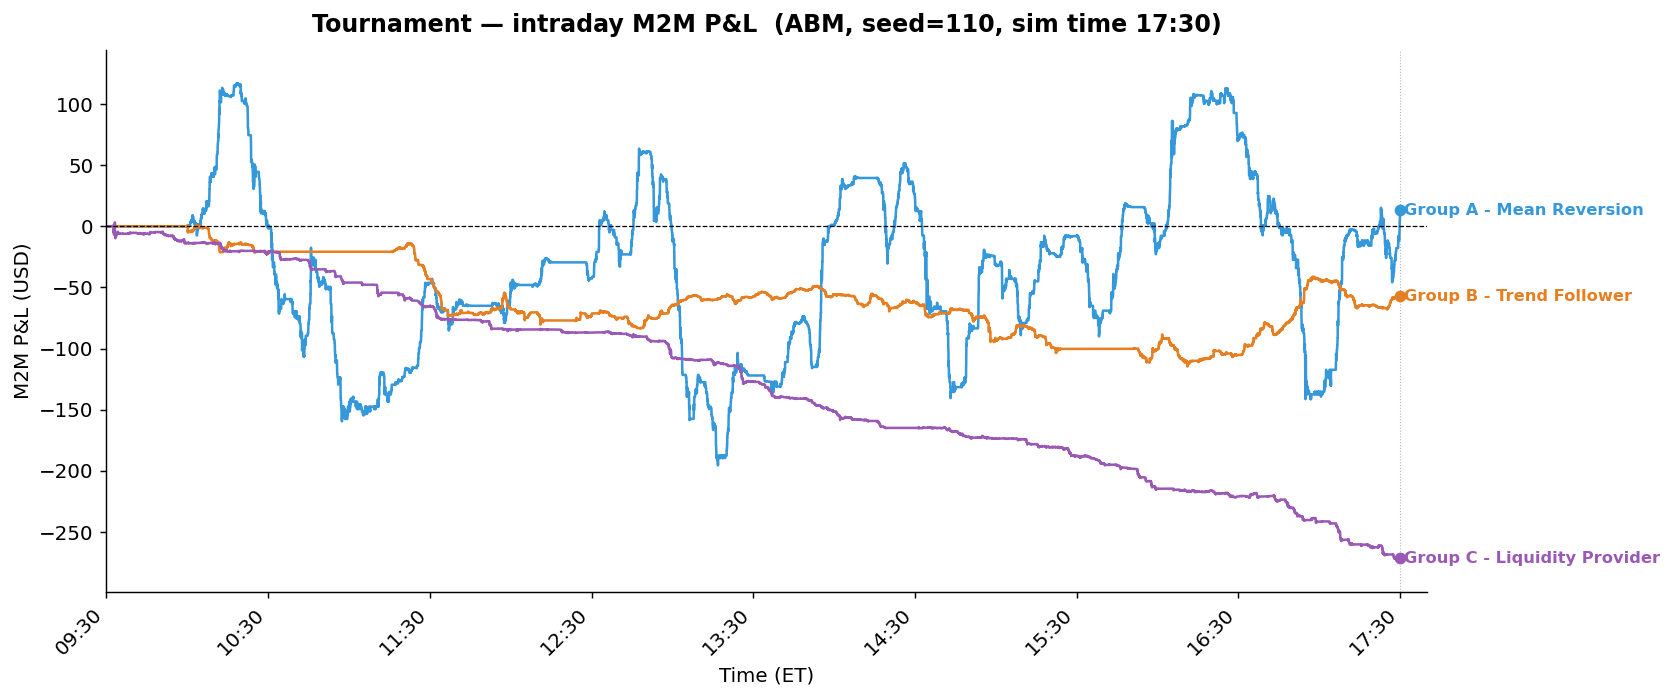

Reveal complete.


In [11]:
# ── Frame schedule: one frame per simulated minute, 09:30 → END_TIME ──────
START_S = int(9.5 * 3600)
end_hh, end_mm, end_ss = (int(x) for x in END_TIME.split(":"))
END_S   = end_hh * 3600 + end_mm * 60 + end_ss
FRAMES  = list(range(START_S, END_S + 1, 60))

# ── Lock Y-limits to the full-day envelope so curves stretch into view ────
all_pnls = pd.concat([results[label]["pnl"] for _, label, _ in AGENTS])
ymin, ymax = float(all_pnls.min()), float(all_pnls.max())
pad = 0.1 * max(abs(ymin), abs(ymax), 1.0)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Label sits this many seconds (sim time) to the right of each leading dot;
# the chart's RIGHT_PAD_S leaves room for the text on the rightmost frame.
LABEL_X_OFFSET_S = 90

for t in FRAMES:
    ax.clear()

    # ── 1. Plot the curves up to the current sim time ─────────────────
    for cls, label, color in AGENTS:
        pnl = results[label]
        visible = pnl[pnl["tod"] <= t]
        ax.plot(visible["tod"], visible["pnl"],
                linewidth=1.4, color=color)

    # ── 2. Collect leading-edge points for the name tags ──────────────
    leaders = []
    for cls, label, color in AGENTS:
        visible = results[label][results[label]["tod"] <= t]
        if not visible.empty:
            leaders.append({
                "label": label,
                "color": color,
                "x":     float(visible["tod"].iloc[-1]),
                "y":     float(visible["pnl"].iloc[-1]),
            })

    # Marker dots at the true frontier of each curve
    for d in leaders:
        ax.scatter([d["x"]], [d["y"]], color=d["color"], s=30, zorder=5)

    # ── 3. Vertically deconflict the tags ─────────────────────────────
    # When two curves cross or sit close together, stacking labels on top
    # of each other is unreadable.  Sort by true y, then push each label
    # above the previous one by at least min_gap (5% of the y-range).
    if leaders:
        span    = (ymax + pad) - (ymin - pad)
        min_gap = 0.05 * span
        leaders.sort(key=lambda d: d["y"])
        last_y = -float("inf")
        for d in leaders:
            d["y_lbl"] = max(d["y"], last_y + min_gap)
            last_y     = d["y_lbl"]

    # ── 4. Draw the name tags (thin leader line when deconflicted) ────
    for d in leaders:
        x_lbl = d["x"] + LABEL_X_OFFSET_S
        if abs(d["y_lbl"] - d["y"]) > 1e-9:
            ax.plot([d["x"], x_lbl], [d["y"], d["y_lbl"]],
                    color=d["color"], linewidth=0.6, alpha=0.5)
        ax.text(
            x_lbl, d["y_lbl"], d["label"],
            color=d["color"], fontsize=9, fontweight="bold",
            va="center", ha="left", clip_on=False,
        )

    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.axvline(t, color="grey",  linewidth=0.6, linestyle=":", alpha=0.6)
    ax.set_xlim(START_S, END_S + RIGHT_PAD_S)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_ylabel("M2M P&L (USD)")
    ax.set_xlabel("Time (ET)")
    hh, mm = divmod(t // 60, 60)
    ax.set_title(
        f"Tournament — intraday M2M P&L  "
        f"({TICKER}, seed={SEED}, sim time {hh:02d}:{mm:02d})",
        fontweight="bold", pad=10,
    )
    ax.spines[["top", "right"]].set_visible(False)
    fmt_xaxis(ax)
    fig.tight_layout()

    clear_output(wait=True)
    display(fig)
    if PAUSE_S:
        time.sleep(PAUSE_S)

plt.close(fig)
print("Reveal complete.")

## 5 · Final league table

In [ ]:
standings = sorted(
    [(label, results[label]["pnl"].iloc[-1], color)
     for cls, label, color in AGENTS],
    key=lambda row: row[1],
    reverse=True,
)

print("=" * 62)
print("  TOURNAMENT LEAGUE TABLE")
print("=" * 62)
print(f"  {'Rank':<5} {'Team':<40} {'PnL':>12}")
print("-" * 62)
for rank, (label, pnl, _) in enumerate(standings, 1):
    arrow = "▲" if pnl >= 0 else "▼"
    print(f"  {rank:<5} {label:<40} {arrow} ${abs(pnl):>9,.2f}")
print("=" * 62)